In [1]:
# Install required libraries (run this once)
!pip install pandas numpy matplotlib seaborn

In [2]:
# ================================================
# PROJECT: Customer Churn Analysis
# TOOLS   : Python, Pandas, Seaborn, Matplotlib
# DATASET : Telco Customer Churn (Kaggle)
# GOAL    : Find why customers are leaving and
#           which customers are most at risk
# ================================================

# Step 1: Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Settings for better looking charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Step 3: Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Step 4: First look at the data
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ================================================
# PHASE 2: DATA CLEANING
# ================================================

# --- 2.1 Basic Info ---
print("=== DATASET INFO ===")
print(df.info())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [4]:
# --- 2.2 Check for Missing Values ---
print("=== MISSING VALUES ===")
print(df.isnull().sum())

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# --- 2.3 Check basic statistics ---
print("=== BASIC STATISTICS ===")
df.describe()

=== BASIC STATISTICS ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# ================================================
# PHASE 2: DATA CLEANING — FIXES
# ================================================

# --- FIX 1: Convert TotalCharges from text to number ---
# Some rows have empty spaces " " — we replace them with NaN first
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# --- FIX 2: Check how many rows got NaN after conversion ---
print("Rows with missing TotalCharges:", df["TotalCharges"].isnull().sum())

Rows with missing TotalCharges: 11


In [7]:
# --- FIX 3: Drop those 11 rows (they are useless without TotalCharges) ---
df.dropna(subset=["TotalCharges"], inplace=True)

# --- FIX 4: Reset the index after dropping rows ---
df.reset_index(drop=True, inplace=True)

print("Dataset shape after cleaning:", df.shape)
# Should show (7032, 21) — 11 rows removed

Dataset shape after cleaning: (7032, 21)


In [8]:
# --- FIX 5: Convert Churn column from Yes/No to 1/0 ---
# This makes it easy to calculate churn rate using math
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# --- FIX 6: Convert SeniorCitizen to readable Yes/No ---
# Right now it's 0/1 which looks confusing in charts
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})

# --- Verify all fixes ---
print("=== AFTER CLEANING ===")
print("Shape:", df.shape)
print("\nData types:")
print(df[["TotalCharges", "Churn", "SeniorCitizen"]].dtypes)
print("\nChurn value counts:")
print(df["Churn"].value_counts())

=== AFTER CLEANING ===
Shape: (7032, 21)

Data types:
TotalCharges     float64
Churn              int64
SeniorCitizen     object
dtype: object

Churn value counts:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [9]:
# --- FIX 7: Rename columns for cleaner look ---
# Remove unnecessary columns we won't use in analysis
df.drop(columns=["customerID"], inplace=True)

print("Final clean dataset shape:", df.shape)
print("\nFirst 3 rows of clean data:")
df.head(3)

Final clean dataset shape: (7032, 20)

First 3 rows of clean data:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


Overall Churn Rate: 26.58%
Customers who stayed : 5163
Customers who left   : 1869


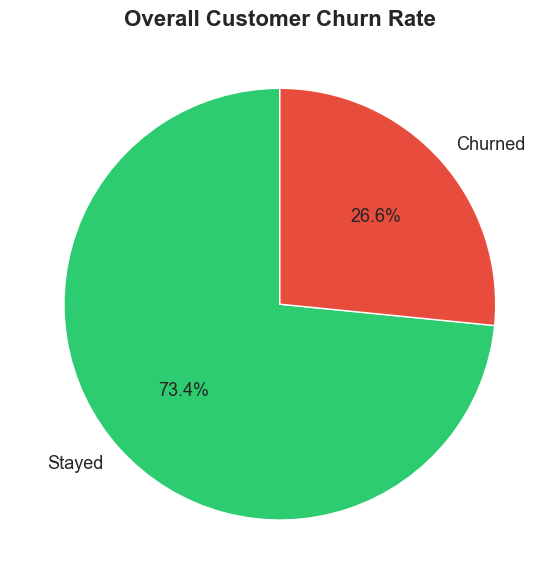

Chart saved!


In [10]:
# ================================================
# PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ================================================

# --- Q1: What is the overall churn rate? ---

churn_rate = df["Churn"].mean() * 100

print(f"Overall Churn Rate: {churn_rate:.2f}%")
print(f"Customers who stayed : {(df['Churn'] == 0).sum()}")
print(f"Customers who left   : {(df['Churn'] == 1).sum()}")

# --- Chart ---
colors = ["#2ecc71", "#e74c3c"]
labels = ["Stayed", "Churned"]
sizes  = [df["Churn"].value_counts()[0], df["Churn"].value_counts()[1]]

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%",
        startangle=90, textprops={"fontsize": 13})
plt.title("Overall Customer Churn Rate", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("chart1_churn_rate.png", dpi=150)
plt.show()
print("Chart saved!")

         Contract  Churn Rate (%)
0  Month-to-month       42.709677
1        One year       11.277174
2        Two year        2.848665


C:\Users\Devendra\AppData\Local\Temp\ipykernel_16032\2428186694.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=contract_churn, x="Contract", y="Churn Rate (%)",


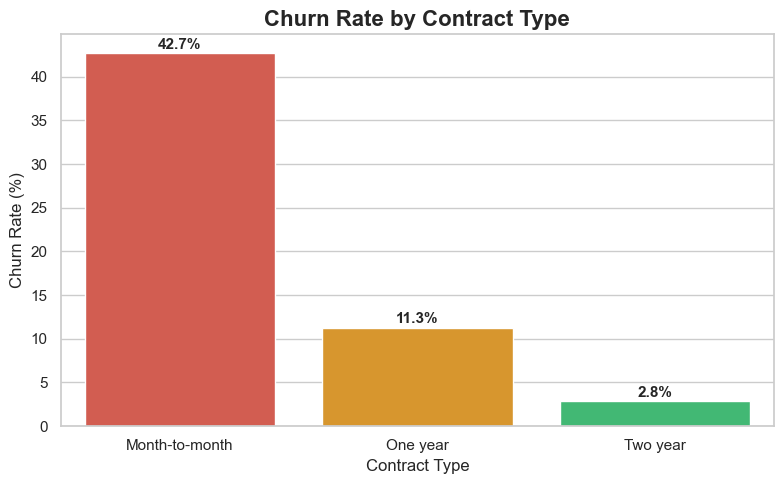

Chart saved!


In [11]:
# --- Q2: Which contract type has highest churn? ---

contract_churn = df.groupby("Contract")["Churn"].mean() * 100
contract_churn = contract_churn.reset_index()
contract_churn.columns = ["Contract", "Churn Rate (%)"]
contract_churn = contract_churn.sort_values("Churn Rate (%)", ascending=False)

print(contract_churn)

plt.figure(figsize=(8, 5))
bars = sns.barplot(data=contract_churn, x="Contract", y="Churn Rate (%)",
                   palette=["#e74c3c", "#f39c12", "#2ecc71"])
plt.title("Churn Rate by Contract Type", fontsize=16, fontweight="bold")
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)

# Add value labels on bars
for bar, val in zip(bars.patches, contract_churn["Churn Rate (%)"]):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 0.5,
              f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("chart2_contract_churn.png", dpi=150)
plt.show()
print("Chart saved!")

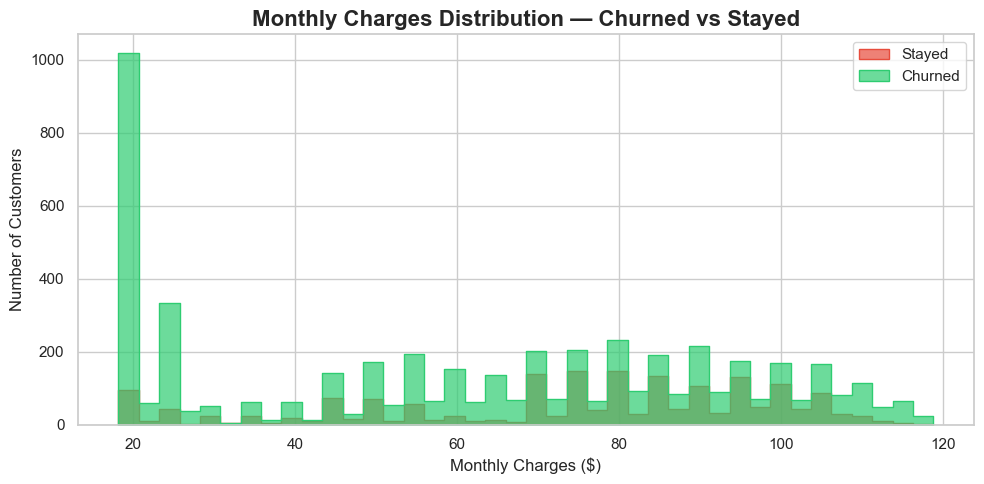

Chart saved!


In [12]:
# --- Q3: Do higher charges lead to more churn? ---

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn",
             palette={0: "#2ecc71", 1: "#e74c3c"},
             bins=40, alpha=0.7, element="step")
plt.title("Monthly Charges Distribution — Churned vs Stayed",
          fontsize=16, fontweight="bold")
plt.xlabel("Monthly Charges ($)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(labels=["Stayed", "Churned"], fontsize=11)
plt.tight_layout()
plt.savefig("chart3_monthly_charges.png", dpi=150)
plt.show()
print("Chart saved!")

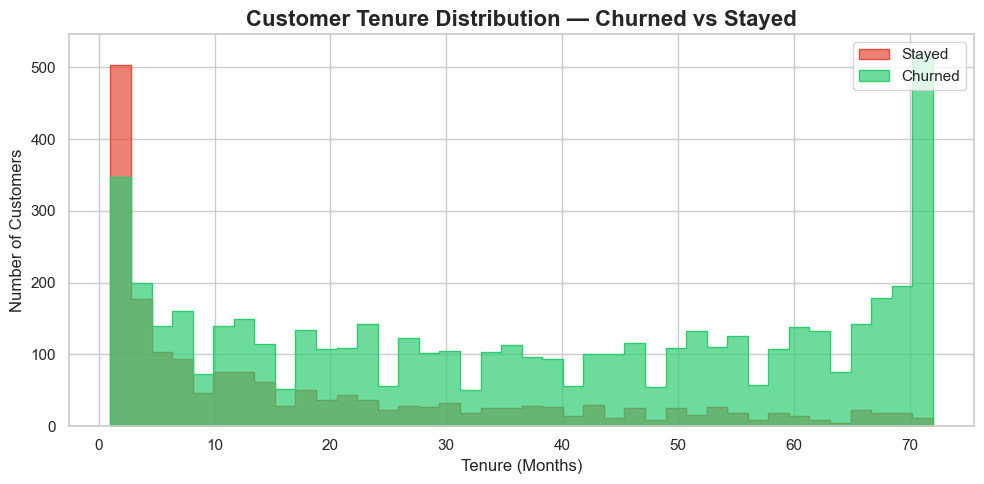

Chart saved!


In [13]:
# --- Q4: Do newer customers churn more? ---

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="tenure", hue="Churn",
             palette={0: "#2ecc71", 1: "#e74c3c"},
             bins=40, alpha=0.7, element="step")
plt.title("Customer Tenure Distribution — Churned vs Stayed",
          fontsize=16, fontweight="bold")
plt.xlabel("Tenure (Months)", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(labels=["Stayed", "Churned"], fontsize=11)
plt.tight_layout()
plt.savefig("chart4_tenure.png", dpi=150)
plt.show()
print("Chart saved!")

  Internet Service  Churn Rate (%)
1      Fiber optic       41.892765
0              DSL       18.998344
2               No        7.434211


C:\Users\Devendra\AppData\Local\Temp\ipykernel_16032\3834623823.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars2 = sns.barplot(data=internet_churn, x="Internet Service",


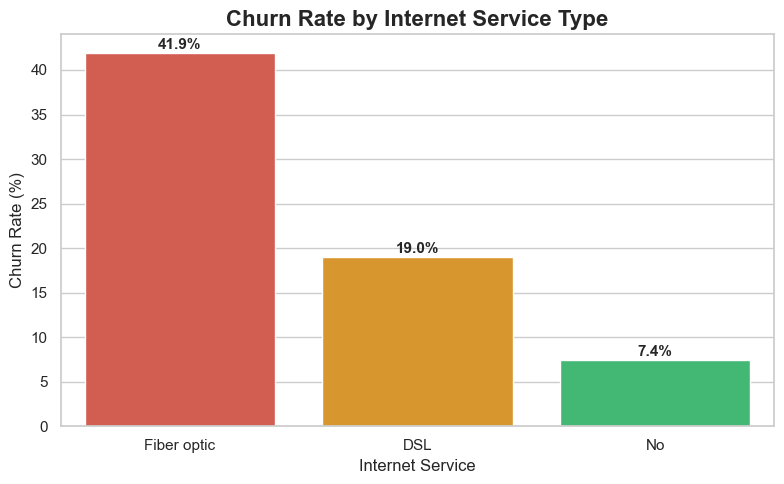

Chart saved!


In [14]:
# --- Q5: Which internet service type churns most? ---

internet_churn = df.groupby("InternetService")["Churn"].mean() * 100
internet_churn = internet_churn.reset_index()
internet_churn.columns = ["Internet Service", "Churn Rate (%)"]
internet_churn = internet_churn.sort_values("Churn Rate (%)", ascending=False)

print(internet_churn)

plt.figure(figsize=(8, 5))
bars2 = sns.barplot(data=internet_churn, x="Internet Service",
                    y="Churn Rate (%)", palette=["#e74c3c","#f39c12","#2ecc71"])
plt.title("Churn Rate by Internet Service Type", fontsize=16, fontweight="bold")
plt.xlabel("Internet Service", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)

for bar, val in zip(bars2.patches, internet_churn["Churn Rate (%)"]):
    bars2.text(bar.get_x() + bar.get_width()/2,
               bar.get_height() + 0.5,
               f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("chart5_internet_service.png", dpi=150)
plt.show()
print("Chart saved!")

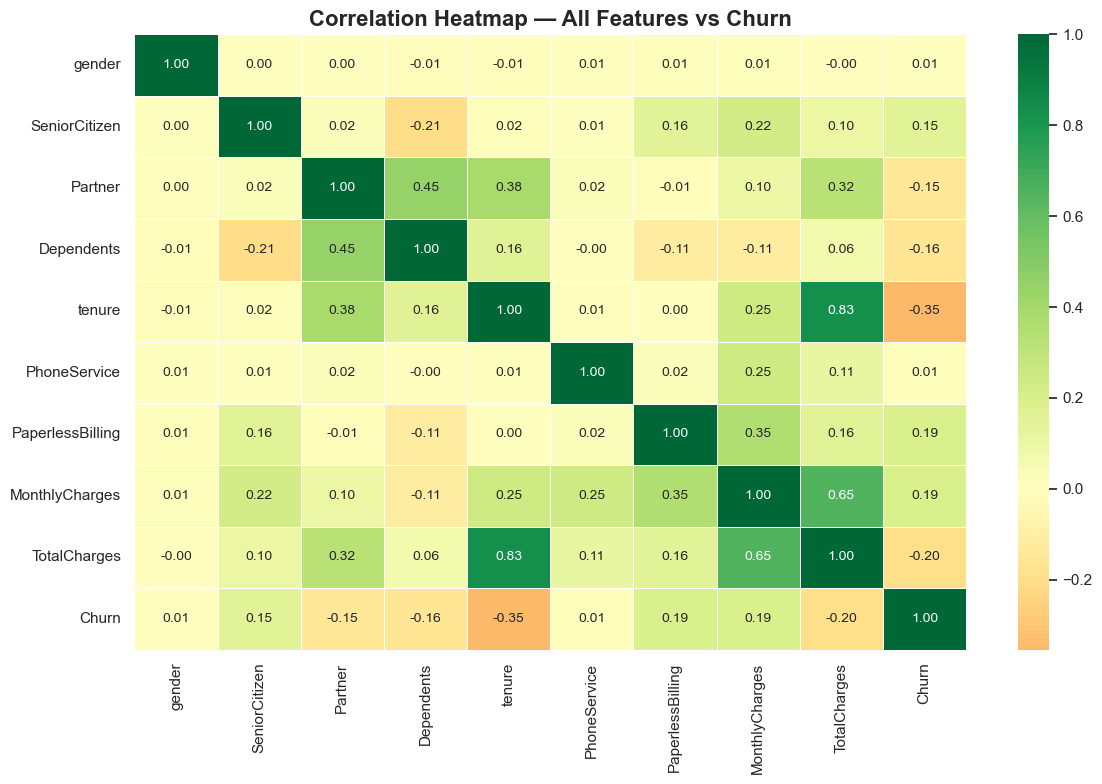

Chart saved!


In [15]:
# --- Q6: Which factors correlate most with churn? ---

# Convert Yes/No columns to 1/0 for correlation
df_corr = df.copy()
yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling",
               "SeniorCitizen", "gender"]

for col in yes_no_cols:
    df_corr[col] = df_corr[col].map({"Yes": 1, "No": 0,
                                      "Female": 1, "Male": 0})

# Keep only numeric columns
numeric_df = df_corr.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f",
            cmap="RdYlGn", center=0,
            linewidths=0.5, annot_kws={"size": 10})
plt.title("Correlation Heatmap — All Features vs Churn",
          fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("chart6_heatmap.png", dpi=150)
plt.show()
print("Chart saved!")

In [16]:
# ================================================
# PHASE 4: SQL ANALYSIS
# ================================================

# We will load our clean data into a SQL database
# and write real SQL queries on it

import sqlite3

# --- Create a database in memory ---
conn = sqlite3.connect("churn_analysis.db")

# --- Load our cleaned dataframe into SQL table ---
df.to_sql("customers", conn, if_exists="replace", index=False)

print("✅ Database created successfully!")
print("✅ Table 'customers' loaded with", len(df), "rows")

✅ Database created successfully!
✅ Table 'customers' loaded with 7032 rows


In [17]:
# --- SQL Q1: What is the overall churn rate? ---

query1 = """
SELECT 
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned_customers,
    ROUND(SUM(Churn) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM customers;
"""

result1 = pd.read_sql_query(query1, conn)
print("=== Q1: Overall Churn Rate ===")
print(result1.to_string(index=False))

=== Q1: Overall Churn Rate ===
 total_customers  churned_customers  churn_rate_pct
            7032               1869           26.58


In [18]:
# --- SQL Q2: Which contract type churns most? ---

query2 = """
SELECT 
    Contract,
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned,
    ROUND(SUM(Churn) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC;
"""

result2 = pd.read_sql_query(query2, conn)
print("=== Q2: Churn Rate by Contract Type ===")
print(result2.to_string(index=False))

=== Q2: Churn Rate by Contract Type ===
      Contract  total_customers  churned  churn_rate_pct
Month-to-month             3875     1655           42.71
      One year             1472      166           11.28
      Two year             1685       48            2.85


In [19]:
# --- SQL Q3: Which internet service has highest churn? ---

query3 = """
SELECT 
    InternetService,
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned,
    ROUND(SUM(Churn) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY InternetService
ORDER BY churn_rate_pct DESC;
"""

result3 = pd.read_sql_query(query3, conn)
print("=== Q3: Churn Rate by Internet Service ===")
print(result3.to_string(index=False))

=== Q3: Churn Rate by Internet Service ===
InternetService  total_customers  churned  churn_rate_pct
    Fiber optic             3096     1297           41.89
            DSL             2416      459           19.00
             No             1520      113            7.43


In [20]:
# --- SQL Q4: Who are the HIGH RISK customers? ---
# High risk = Month-to-month contract + Fiber optic + High charges

query4 = """
SELECT 
    Contract,
    InternetService,
    PaperlessBilling,
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned,
    ROUND(SUM(Churn) * 100.0 / COUNT(*), 2) AS churn_rate_pct,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charge
FROM customers
WHERE Contract = 'Month-to-month' 
  AND InternetService = 'Fiber optic'
GROUP BY Contract, InternetService, PaperlessBilling
ORDER BY churn_rate_pct DESC;
"""

result4 = pd.read_sql_query(query4, conn)
print("=== Q4: High Risk Customer Segment ===")
print(result4.to_string(index=False))

=== Q4: High Risk Customer Segment ===
      Contract InternetService PaperlessBilling  total_customers  churned  churn_rate_pct  avg_monthly_charge
Month-to-month     Fiber optic              Yes             1689      962           56.96               87.58
Month-to-month     Fiber optic               No              439      200           45.56               84.88


In [21]:
# --- SQL Q5: Churn rate by customer age group (tenure buckets) ---

query5 = """
SELECT 
    CASE 
        WHEN tenure <= 12  THEN '0-12 months (New)'
        WHEN tenure <= 24  THEN '13-24 months'
        WHEN tenure <= 48  THEN '25-48 months'
        ELSE '49+ months (Loyal)'
    END AS tenure_group,
    COUNT(*) AS total_customers,
    SUM(Churn) AS churned,
    ROUND(SUM(Churn) * 100.0 / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY tenure_group
ORDER BY churn_rate_pct DESC;
"""

result5 = pd.read_sql_query(query5, conn)
print("=== Q5: Churn Rate by Tenure Group ===")
print(result5.to_string(index=False))

=== Q5: Churn Rate by Tenure Group ===
      tenure_group  total_customers  churned  churn_rate_pct
 0-12 months (New)             2175     1037           47.68
      13-24 months             1024      294           28.71
      25-48 months             1594      325           20.39
49+ months (Loyal)             2239      213            9.51


In [22]:
# --- Save SQL results to Excel for portfolio ---
with pd.ExcelWriter("sql_analysis_results.xlsx") as writer:
    result1.to_excel(writer, sheet_name="Overall Churn",    index=False)
    result2.to_excel(writer, sheet_name="By Contract",      index=False)
    result3.to_excel(writer, sheet_name="By Internet",      index=False)
    result4.to_excel(writer, sheet_name="High Risk Segment",index=False)
    result5.to_excel(writer, sheet_name="By Tenure Group",  index=False)

conn.close()
print("✅ SQL results saved to sql_analysis_results.xlsx")
print("✅ SQL Phase Complete!")

✅ SQL results saved to sql_analysis_results.xlsx
✅ SQL Phase Complete!


In [23]:
# ================================================
# PHASE 5: KEY BUSINESS INSIGHTS & RECOMMENDATIONS
# ================================================

summary = """
╔══════════════════════════════════════════════════════════════════╗
║           CUSTOMER CHURN ANALYSIS — KEY FINDINGS                ║
║                    Telco Company Dataset                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET : 7,032 customers | 20 features                        ║
║  TOOLS   : Python, Pandas, Seaborn, Matplotlib, SQL (SQLite)    ║
║  AUTHOR  : Devendra                                              ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  INSIGHT 1 — Overall Churn Rate                                  ║
║  26.58% of customers churned (1,869 out of 7,032)               ║
║  → 1 in 4 customers is leaving the company                      ║
║                                                                  ║
║  INSIGHT 2 — Contract Type is the #1 Churn Driver               ║
║  Month-to-month : 42.71% churn                                  ║
║  One year       : 11.28% churn                                  ║
║  Two year       :  2.85% churn                                  ║
║  → Locking customers into longer contracts reduces churn by 15x ║
║                                                                  ║
║  INSIGHT 3 — Fiber Optic Customers at High Risk                  ║
║  Fiber optic : 41.89% churn vs DSL : 19.00%                    ║
║  → Possible service quality or pricing issues with Fiber optic  ║
║                                                                  ║
║  INSIGHT 4 — New Customers are Most Vulnerable                   ║
║  0-12 months  : 47.68% churn                                    ║
║  49+ months   :  9.51% churn                                    ║
║  → First year is critical — needs strong onboarding program     ║
║                                                                  ║
║  INSIGHT 5 — Highest Risk Segment Identified                     ║
║  Month-to-month + Fiber optic + Paperless billing = 56.96% churn║
║  This segment (1,689 customers) is the top priority to retain   ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  BUSINESS RECOMMENDATIONS                                        ║
║                                                                  ║
║  REC 1: Offer discounts to move customers to yearly contracts   ║
║  REC 2: Create a 90-day onboarding program for new customers    ║
║  REC 3: Investigate Fiber optic pricing & service quality       ║
║  REC 4: Target the 1,689 high-risk customers with retention     ║
║         offers before they cancel                               ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════╗
║           CUSTOMER CHURN ANALYSIS — KEY FINDINGS                ║
║                    Telco Company Dataset                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET : 7,032 customers | 20 features                        ║
║  TOOLS   : Python, Pandas, Seaborn, Matplotlib, SQL (SQLite)    ║
║  AUTHOR  : Devendra                                              ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  INSIGHT 1 — Overall Churn Rate                                  ║
║  26.58% of customers churned (1,869 out of 7,032)               ║
║  → 1 in 4 customers is leaving the company                      ║
║                                                                  ║
║  INSIGHT 2 — Contract Type is the #1